# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Scrappear Pagina 12 | Uso de distintos métodos y herramientas. Le pedí modificar la función creada en TP1 para implementar un scrapping en Página 12. | Recomendó el uso de request y Beutiful soup, usó de trafilatura + bs4. Uso de Playwright | Luego de varias pruebas y error con diferentes librerías opté por el uso de playwright | Descarté combinaciones de algunas librerías ya que aunque obtenía la metadata no podía capturar el texto completo | 
| Procesamiento con spaCy | No se mostraban entidades de Página 12 y al agregar código para borrar entidades estás seguían apareciendo | Eliminar entidades y mostrar en tabla las entidades de ambos grupos | Sugirió varios motivos: el modelo es_core_news_sm no las identifica correctamente, el grupo no tiene entidades, filtro de entidades aplicado, corpus desbalanceado | Luego de probar modificando el código se observó que no era un problema del modelo, ni del grupo, ni del corpus sino un error en el códddigo inicial | Se descartó modificar el modelo, el desbalanceo del corpus y la posibilidad de que el grupo no tenga entidades |
| Representaciones sparse | | | | | |
| Visualización | | | | | |
| Interpretación final | | | | | |


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [131]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [132]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus/corpus.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus\corpus.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [133]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta, sep=";")
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 8
Grupos detectados: ['la nación', 'pagina 12']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,0,2026-03-06,LA NACION,Melisa Reinhold,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,1019
1,1,2026-02-28,LA NACION,Laura Serra,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios",la nación,1837
2,2,2026-04-08,LA NACION,Manuela Viñales,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,la nación,898
3,3,2026-02-12,LA NACION,Francisco Jueguen,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,la nación,1624
4,4,2026-02-13,Página|12,Celeste del Bianco,Todos los derechos con los que arrasa la reforma laboral de Milei,pagina 12,1152
5,5,2026-03-06,Página|12,Luciano Monteagudo,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores",pagina 12,1338
6,6,2026-02-22,Página|12,Hernán Letcher,El futuro del trabajo con la reforma laboral,pagina 12,1455
7,7,2026-03-07,Página|12,Mara Pedrazzoli,El impacto de la reforma laboral,pagina 12,782


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


* Se busca comparar el vocabulario de dos medios al referirse a la Reforma laboral.
* Se eligió este corpus en base a la temática y se buscó artículos que hayan sido publicados dentro de un período de tiempo acotado. Entre febrero y abril del 2026. Se seleccionaron textos de diferentes autores.
* Cada grupo esta compuesto por artículos referentes a la misma temática, en el mismo período de tiempo. Se tomaron 4 artículos por medio.
* El corpus tiene solamente 8 texto, 4 por artículo, esto puede ser límitante al querer encontrar patrones. Cada texto tiene entrre 700 y 1800 palabra. Podría verse un desbalance en la cantidad de palabras utilizaas en los artículos de La Nación.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [134]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,8
1,palabras aproximadas,10105
2,promedio por texto,1263.1
3,grupo 1,la nación
4,grupo 2,pagina 12


In [135]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,la nación,4,5378,1344.50
1,pagina 12,4,4727,1181.75


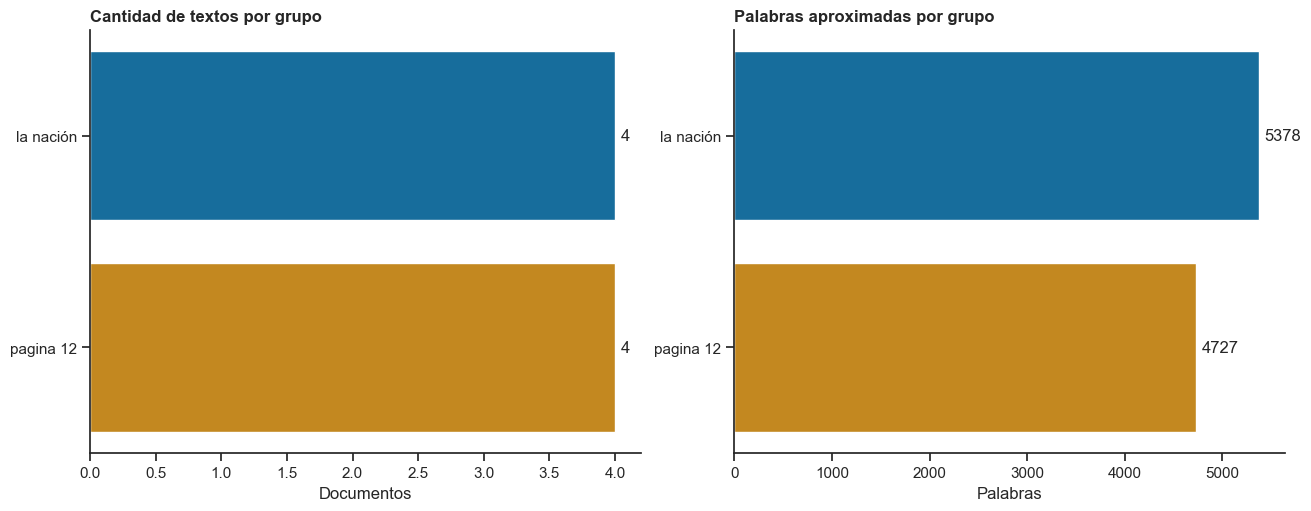

In [136]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


Se observa que los artículos de La Nación suman mas palabras (5378 vs 4727). La diferencia 651 genera un pequeño desbalance entre ambos grupos. Ese desbalance no supera al artículo con menos palabras del corpus.

## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [137]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


In [138]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,promulgar reforma laboral impacto real vida empresa empleado ley unifico cálculo indemnización flexibilizar contratación habilitar cambi...
1,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios",la nación,reforma laboral milei aprobar senado principal cambio gobierno javier milei conseguir sancionar viernes reforma laboral trámite revisión...
2,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,la nación,mes ley modernización laboral publicar boletín oficial medida quedar efectivo eje central laboral artículo incorporar reforma impositiva...
3,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,la nación,contundente respaldo empresario avance reforma laboral congreso cámaras asociación apoyar aprobación modernización senado afirmar ordena...
4,Todos los derechos con los que arrasa la reforma laboral de Milei,pagina 12,reforma laboral gobierno impulsar insistencia madrugada jueves medio sanción senado destruir derecho trabajador vía atacar contrato indi...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [139]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,la nación,laboral,53
1,la nación,trabajador,28
2,la nación,ley,25
3,la nación,reforma,23
4,la nación,empresa,23
5,la nación,empleo,21
6,la nación,trabajo,20
7,la nación,generar,17
8,la nación,empleador,17
9,la nación,argentina,16


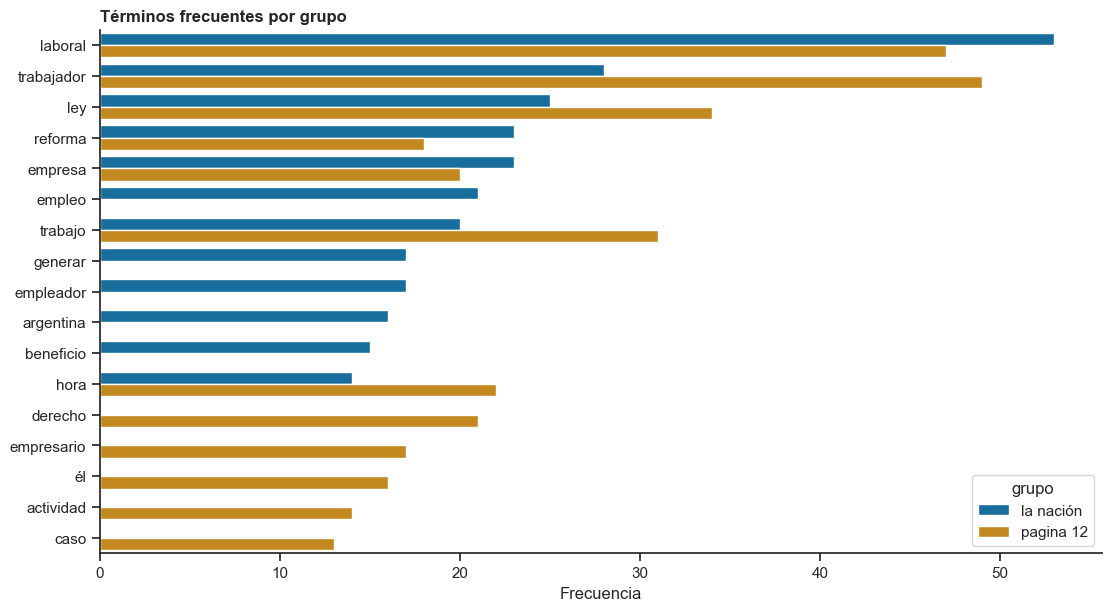

In [140]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [ ]:
# se agregaría él a stopwords

In [141]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
159,la nación,Senado,ORG,8
185,la nación,la Argentina,LOC,7
197,la nación,¿Qué,MISC,7
178,la nación,agregó,PER,6
16,la nación,Argentina,LOC,5
38,la nación,Domínguez,PER,4
76,la nación,Gobierno,LOC,4
129,la nación,NACION,ORG,4
170,la nación,También,PER,4
196,la nación,¿Qué,LOC,4


In [142]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })
# Después de df_entidades = pd.DataFrame(registros_entidades)
print("Entidades detectadas por grupo:")
print(df_entidades["grupo"].value_counts())  # Muestra cuántas entidades por grupo
print("Grupos en df_entidades:", df_entidades["grupo"].unique())
print("Total entidades:", len(df_entidades))

# También, para verificar entidades por texto:
for grupo in df[COLUMNA_GRUPO].unique():
    sub = df[df[COLUMNA_GRUPO] == grupo]
    total_ent = sum(len(fila.entidades) for fila in sub.itertuples(index=False))
    print(f"Grupo '{grupo}': {len(sub)} textos, {total_ent} entidades totales")

Entidades detectadas por grupo:
grupo
la nación    266
pagina 12    262
Name: count, dtype: int64
Grupos en df_entidades: <StringArray>
['la nación', 'pagina 12']
Length: 2, dtype: str
Total entidades: 528
Grupo 'la nación': 4 textos, 266 entidades totales
Grupo 'pagina 12': 4 textos, 262 entidades totales


In [143]:
# Muestro el top de entidades por grupo

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
    )
    
    # Mostrar top por grupo
    for grupo in sorted(top_entidades["grupo"].unique()):
        sub_top = (
            top_entidades[top_entidades["grupo"] == grupo]
            .sort_values("frecuencia", ascending=False)
            .head(TOP_N)
        )
        print(f"Top {TOP_N} entidades para grupo '{grupo}':")
        display(sub_top)
        print("\n")  # Separador
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")

Top 12 entidades para grupo 'la nación':


,grupo,texto_entidad,etiqueta,frecuencia
159,la nación,Senado,ORG,8
197,la nación,¿Qué,MISC,7
185,la nación,la Argentina,LOC,7
178,la nación,agregó,PER,6
16,la nación,Argentina,LOC,5
38,la nación,Domínguez,PER,4
129,la nación,NACION,ORG,4
76,la nación,Gobierno,LOC,4
170,la nación,También,PER,4
196,la nación,¿Qué,LOC,4




Top 12 entidades para grupo 'pagina 12':


,grupo,texto_entidad,etiqueta,frecuencia
261,pagina 12,FAL,MISC,6
269,pagina 12,Gobierno,LOC,5
321,pagina 12,Milei,LOC,5
365,pagina 12,Senado,ORG,5
305,pagina 12,Ley de Contrato de Trabajo,MISC,5
208,pagina 12,Argentina,LOC,4
373,pagina 12,También,PER,4
229,pagina 12,Cremonte,LOC,4
222,pagina 12,Campos,LOC,3
225,pagina 12,Ciudad de Buenos Aires,LOC,3


In [128]:
# Muestro el top de entidades por grupo
# elimino entidades
TERMINOS_EXCLUIDOS  = {
    "ganancias", "también", "?", "sra", "¿", "¿qué", 
    "agregó", "modernización laboral", "¿habrá", "ley", "pen"
}
ETIQUETAS_EXCLUIDAS = ["DATE", "MONEY", "PERCENT", "TIME"]  # Ejemplo: excluye fechas, dinero, etc.


MAPEO_ENTIDADES = {
    "la Argentina": "Argentina",
    "Javier Milei": "Milei"
}

df_entidades = df_entidades[
    (df_entidades["etiqueta"].isin(ETIQUETAS_EXCLUIDAS) == False) &  # Excluye etiquetas
    (df_entidades["texto_entidad"].str.lower().isin([t.lower() for t in TERMINOS_EXCLUIDOS]) == False)  # Excluye términos
]

df_entidades["texto_entidad"] = df_entidades["texto_entidad"].replace(MAPEO_ENTIDADES)
# Luego, el código de top_entidades por grupo (de la respuesta anterior)
if not df_entidades.empty:
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
    )
    
    for grupo in sorted(top_entidades["grupo"].unique()):
        sub_top = (
            top_entidades[top_entidades["grupo"] == grupo]
            .sort_values("frecuencia", ascending=False)
            .head(TOP_N)
        )
        print(f"Top {TOP_N} entidades para grupo '{grupo}' (excluyendo irrelevantes):")
        display(sub_top)
        print("\n")
else:
    print("No se detectaron entidades después del filtro.")

Top 12 entidades para grupo 'la nación' (excluyendo irrelevantes):


,grupo,texto_entidad,etiqueta,frecuencia
16,la nación,Argentina,LOC,12
152,la nación,Senado,ORG,8
73,la nación,Gobierno,LOC,4
124,la nación,NACION,ORG,4
38,la nación,Domínguez,PER,4
64,la nación,FAL,MISC,3
20,la nación,Bolsa de Comercio,ORG,2
23,la nación,CAC,LOC,2
4,la nación,Adeba,LOC,2
1,la nación,ABA,LOC,2




Top 12 entidades para grupo 'pagina 12' (excluyendo irrelevantes):


,grupo,texto_entidad,etiqueta,frecuencia
194,pagina 12,Argentina,LOC,6
247,pagina 12,FAL,MISC,6
255,pagina 12,Gobierno,LOC,5
350,pagina 12,Senado,ORG,5
306,pagina 12,Milei,LOC,5
290,pagina 12,Ley de Contrato de Trabajo,MISC,5
215,pagina 12,Cremonte,LOC,4
211,pagina 12,Ciudad de Buenos Aires,LOC,3
191,pagina 12,Además,PER,3
252,pagina 12,Fondo de Asistencia Laboral,ORG,3


In [110]:
# Cargamos un modelo limpio (sin modificaciones previas)
nlp_mejorado = spacy.load("es_core_news_sm")

# Creamos el EntityRuler y lo insertamos ANTES del componente 'ner'
config = {"overwrite_ents": True}
ruler = nlp_mejorado.add_pipe("entity_ruler", config=config, before="ner")

# Diccionario de entidades locales
patrones_locales = [
    # Organismos gubernamentales
    {"label": "ORG", "pattern": "Gobierno"},
    {"label": "ORG", "pattern": "CAC"},
    {"label": "ORG", "pattern": "Adeba"},
    {"label": "ORG", "pattern": "ABA"},
    # PER
    {"label": "PER", "pattern": "Milei"},
    {"label": "PER", "pattern": "Javier Milei"},
    # Ubicaciones
    {"label": "LOC", "pattern": "CABA"},
    {"label": "LOC", "pattern": "AMBA"},
    # Patrones multi-token
    {"label": "ORG", "pattern": "Casa Rosada"},
    {"label": "ORG", "pattern": [{"LOWER": "ministerio"}, {"LOWER": "de"}, {"LOWER": "trabajo"}]},
    # MISC
    {"label": "MISC", "pattern": "Bolsa de Comercio"}
]

ruler.add_patterns(patrones_locales)
print(f"Pipeline modificado: {nlp_mejorado.pipe_names}")

Pipeline modificado: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']


In [144]:
df

,id,fecha,medio,autor,titulo,texto,grupo_comparacion,num_palabras,texto_lemas,texto_contenido,entidades
0,0,2026-03-06,LA NACION,Melisa Reinhold,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados\nLa nueva ley unifica el cálculo d...,la nación,1019,él promulgar el reforma laboral : cuál ser el impacto real en el vida de el empresa y de su empleado el nuevo ley unifico el cálculo de ...,promulgar reforma laboral impacto real vida empresa empleado ley unifico cálculo indemnización flexibilizar contratación habilitar cambi...,"[{'texto': 'cuál', 'etiqueta': 'LOC'}, {'texto': 'buscará', 'etiqueta': 'PER'}, {'texto': 'Habrá', 'etiqueta': 'PER'}, {'texto': 'Los an..."
1,1,2026-02-28,LA NACION,Laura Serra,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios","Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios\nEl gobierno de Javier Milei consiguió san...",la nación,1837,"qué ser el reforma laboral de milei que aprobar el senado : uno por uno , el principal cambio el gobierno de javier milei conseguir sanc...",reforma laboral milei aprobar senado principal cambio gobierno javier milei conseguir sancionar viernes reforma laboral trámite revisión...,"[{'texto': 'Qué', 'etiqueta': 'LOC'}, {'texto': 'Milei', 'etiqueta': 'LOC'}, {'texto': 'Senado', 'etiqueta': 'ORG'}, {'texto': 'Javier M..."
2,2,2026-04-08,LA NACION,Manuela Viñales,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,"Hace poco más de un mes, la Ley de Modernización Laboral se publicó en el Boletín Oficial, y de esa manera sus medidas quedaron efectiva...",la nación,898,"hacer poco más de uno mes , el ley de modernización laboral él publicar en el boletín oficial , y de ese manera su medida quedar efectiv...",mes ley modernización laboral publicar boletín oficial medida quedar efectivo eje central laboral artículo incorporar reforma impositiva...,"[{'texto': 'Ley', 'etiqueta': 'MISC'}, {'texto': 'Modernización Laboral', 'etiqueta': 'PER'}, {'texto': 'Boletín Oficial', 'etiqueta': '..."
3,3,2026-02-12,LA NACION,Francisco Jueguen,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso\nCámaras y asociaciones apoyaron la aprobación de...,la nación,1624,contundente respaldo de el empresario al avance de el reforma laboral en el congreso cámaras y asociación apoyar el aprobación de el mod...,contundente respaldo empresario avance reforma laboral congreso cámaras asociación apoyar aprobación modernización senado afirmar ordena...,"[{'texto': 'Congreso Cámaras', 'etiqueta': 'MISC'}, {'texto': 'Senado', 'etiqueta': 'ORG'}, {'texto': 'Senado', 'etiqueta': 'ORG'}, {'te..."
4,4,2026-02-13,Página|12,Celeste del Bianco,Todos los derechos con los que arrasa la reforma laboral de Milei,"La reforma laboral que el Gobierno impulsa con insistencia y que en la madrugada del jueves tuvo media sanción en el Senado, destruye el...",pagina 12,1152,"el reforma laboral que el gobierno impulsar con insistencia y que en el madrugada del jueves tener medio sanción en el senado , destruir...",reforma laboral gobierno impulsar insistencia madrugada jueves medio sanción senado destruir derecho trabajador vía atacar contrato indi...,"[{'texto': 'Gobierno impulsa', 'etiqueta': 'LOC'}, {'texto': 'Senado', 'etiqueta': 'ORG'}, {'texto': 'Ataca', 'etiqueta': 'LOC'}, {'text..."
5,5,2026-03-06,Página|12,Luciano Monteagudo,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores",El Gobierno nacional promulgó la ley de Reforma Laboral con la que quitó a los trabajadores cuantiosos derechos ganados durante décadas ...,pagina 12,1338,el gobierno nacional promulgar el ley de re

In [145]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,la nación,relación laboral,8
1,la nación,empleo formal,8
2,la nación,reforma laboral,7
3,la nación,creación empleo,5
4,la nación,convenio colectivo,4
5,la nación,persona humano,4
6,la nación,reducir litigiosidad,4
7,la nación,fraccionamiento vacación,4
8,la nación,incentivo formalización,4
9,la nación,impuesto ganancias,4


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


Entidades a limpiar: 
* ¿Qué	MISC
* la Argentina cambiar por Argentina
* agregó	PER	
* También	PER	

## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [146]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,la nación,promulgar reforma laboral impacto real vida empresa empleado ley unifico cálculo indemnización flexibilizar contratación habilitar cambi...
1,pagina 12,reforma laboral gobierno impulsar insistencia madrugada jueves medio sanción senado destruir derecho trabajador vía atacar contrato indi...


In [147]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,la nación,alquiler,13.0
1,la nación,inversión,11.0
2,la nación,exención,10.0
3,la nación,previsibilidad,9.0
4,la nación,fiscal,8.0
5,la nación,productivo,8.0
6,la nación,comercio,7.0
7,la nación,ganancias,7.0
8,la nación,marco,6.0
9,la nación,humano,6.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,la nación,alquiler,0.2522
1,la nación,inversión,0.2134
2,la nación,exención,0.1940
3,la nación,previsibilidad,0.1746
4,la nación,fiscal,0.1552
5,la nación,productivo,0.1552
6,la nación,comercio,0.1358
7,la nación,ganancias,0.1358
8,la nación,marco,0.1164
9,la nación,humano,0.1164


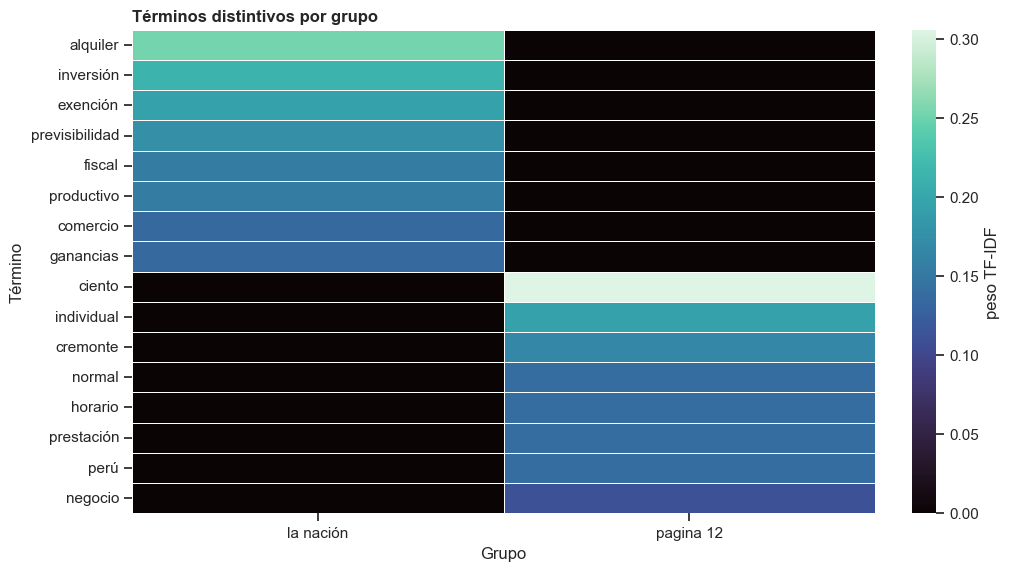

In [148]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [149]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,la nación,alquiler,0.2522
1,la nación,inversión,0.2134
2,pagina 12,ciento,0.3058
3,pagina 12,individual,0.1946


In [150]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,la nación,alquiler,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios","...el fondo que financia la actividad cinematográfica, que se nutre de un impuesto del 10% sobre las entradas de cine, un 10% sobre la v..."
1,la nación,alquiler,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,...rmas impositivas relacionadas con el mercado inmobiliario: la exención del Impuesto a las Ganancias tanto para quien tiene una propie...
2,la nación,inversión,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,"...icio laboral a las pymes las liquida: tenían que pagar millones de millones, hipotecar sus empresas, perder ganancias que se iban a u..."
3,la nación,inversión,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,...i hay muchas inversiones y aumentan los precios de los inmuebles -producto de una mayor demanda- como el alquiler es una rentabilidad...
4,la nación,inversión,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,"...nuevas oportunidades para las nuevas generaciones. El desafío es claro: una Argentina que vuelva a desarrollarse, genere empleo forma..."
5,pagina 12,ciento,Todos los derechos con los que arrasa la reforma laboral de Milei,"...sanciona, aquella persona que tenga una enfermedad que no sea consecuencia de la prestación de las tareas laborales cobrará solo el 5..."
6,pagina 12,ciento,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores","..., pero no las horas extras, los denominados “plus” ni las gratificaciones extraordinarias.\n\nLa base de todo ello no podrá superar e..."
7,pagina 12,ciento,El futuro del trabajo con la reforma laboral,"...oro y plata. El primero dejó 920 personas en la calle. El segundo, generará, apenas, unos 600 puestos de trabajo cuando esté funciona..."
8,pagina 12,individual,Todos los derechos con los que arrasa la reforma laboral de Milei,"...adrugada del jueves tuvo media sanción en el Senado, destruye el derecho de las y los trabajadores por tres grandes vías. Ataca el co..."
9,pagina 12,individual,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores","...ar ni disponer el contenido de los convenios de ámbito menor”.\n\nA partir de ahora, cada empresa podrá negociar con sus empleados, d..."


In [151]:
with pd.option_context('display.max_colwidth', None):
    display(fragmentos)

,grupo,término,título,fragmento
0,la nación,alquiler,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios","...el fondo que financia la actividad cinematográfica, que se nutre de un impuesto del 10% sobre las entradas de cine, un 10% sobre la venta o alquiler de videogramas y un 25% de la recaudación del Enacom. El texto original preveía su eliminación inmediata.\nIncentivos para medianas empresas..."
1,la nación,alquiler,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,...rmas impositivas relacionadas con el mercado inmobiliario: la exención del Impuesto a las Ganancias tanto para quien tiene una propiedad en alquiler con destino casa habitación (vivienda) como para las personas humanas que venden un inmueble.\nEl efecto de estas reformas es a partir del 1...
2,la nación,inversión,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,"...icio laboral a las pymes las liquida: tenían que pagar millones de millones, hipotecar sus empresas, perder ganancias que se iban a usar en inversión. Cualquiera iba a juicio porque algo iba a poder sacar y eso era un desincentivo a la contratación. Con esta normativa, se ordenan y elimin..."
3,la nación,inversión,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,"...i hay muchas inversiones y aumentan los precios de los inmuebles -producto de una mayor demanda- como el alquiler es una rentabilidad de la inversión, puede ser que los alquileres suban y se mantengan; de esta manera los inquilinos no verán los precios de los alquileres más bajos.\nEsta me..."
4,la nación,inversión,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,"...nuevas oportunidades para las nuevas generaciones. El desafío es claro: una Argentina que vuelva a desarrollarse, genere empleo formal, más inversión y oportunidades de acuerdo con las distintas realidades locales. Ese es el camino hacia una Argentina federal en desarrollo”, cerraron."
5,pagina 12,ciento,Todos los derechos con los que arrasa la reforma laboral de Milei,"...sanciona, aquella persona que tenga una enfermedad que no sea consecuencia de la prestación de las tareas laborales cobrará solo el 50 por ciento del sueldo que percibía al momento del accidente durante 3 meses o 6 si tiene personas a cargo. Los libertarios fueron un poco más generoso..."
6,pagina 12,ciento,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores","..., pero no las horas extras, los denominados “plus” ni las gratificaciones extraordinarias.\n\nLa base de todo ello no podrá superar el 67 por ciento del valor del convenio. Y para el caso de los despidos “sin causa”, la indemnización será equivalente a solo un mes de sueldo por cada año..."
7,pagina 12,ciento,El futuro del trabajo con la reforma laboral,"...oro y plata. El primero dejó 920 personas en la calle. El segundo, generará, apenas, unos 600 puestos de trabajo cuando esté funcionando al ciento por ciento, recién en varios años ¿Es posible compensar unos con otros? La reconversión de empresas que cierran y de trabajadores que pierd..."
8,pagina 12,individual,Todos los derechos con los que arrasa la reforma laboral de Milei,"...adrugada del jueves tuvo media sanción en el Senado, destruye el derecho de las y los trabajadores por tres grandes vías. Ataca el contrato individual –con la creación del banco de horas, el fraccionamiento de las vacaciones o el recorte a las licencias por enfermedad–, debilita la acción..."
9,pagina 12,individual,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores","...ar ni disponer el contenido de los convenios de ámbito menor”.\n\nA partir de ahora, cada empresa podrá negociar con sus empleados, de manera individual, condiciones inferiores al piso establecido por el convenio de una rama

In [152]:
for i, row in fragmentos.iterrows():
    print(f"Fila {i}: Término '{row['término']}' en fragmento: {row['término'] in row['fragmento']}")
    if len(row['fragmento']) > 150:
        print(f"Fragmento completo (primeros 500 chars): {row['fragmento'][:500]}")

Fila 0: Término 'alquiler' en fragmento: True
Fragmento completo (primeros 500 chars): ...el fondo que financia la actividad cinematográfica, que se nutre de un impuesto del 10% sobre las entradas de cine, un 10% sobre la venta o alquiler de videogramas y un 25% de la recaudación del Enacom. El texto original preveía su eliminación inmediata.
Incentivos para medianas empresas...
Fila 1: Término 'alquiler' en fragmento: True
Fragmento completo (primeros 500 chars): ...rmas impositivas relacionadas con el mercado inmobiliario: la exención del Impuesto a las Ganancias tanto para quien tiene una propiedad en alquiler con destino casa habitación (vivienda) como para las personas humanas que venden un inmueble.
El efecto de estas reformas es a partir del 1...
Fila 2: Término 'inversión' en fragmento: True
Fragmento completo (primeros 500 chars): ...icio laboral a las pymes las liquida: tenían que pagar millones de millones, hipotecar sus empresas, perder ganancias que se iban a usar en inver

## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


In [ ]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
